# DAV Recruitment Assignment 2026-27
## Question 1a: Data Preprocessing & EDA  |  Question 1b: Regression Modeling
**IIT Bombay UG Student Dataset**


## 1. Imports and Setup
We begin by importing the standard data science libraries we'll need throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset
We load the CSV and do an initial inspection of its shape, column names, data types, and a few sample rows.

In [2]:
df = pd.read_csv('IITB_UG_Student_Dataset.csv')
print(f'Shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())
df.head()

Shape: (1003, 19)

Column names:
['Student_ID', 'Age', 'Gender', 'StudyHoursPerDay', 'SocialMediaHours', 'PassiveEntertainmentHrs', 'PoR', 'AttendancePercentage', 'SleepHoursPerNight', 'Diet_Quality', 'Exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'Cumulative_Grade', 'ProductivityScore', 'SleepDebt', 'TotalScreenTime']


,Student_ID,Age,Gender,StudyHoursPerDay,SocialMediaHours,PassiveEntertainmentHrs,PoR,AttendancePercentage,SleepHoursPerNight,Diet_Quality,Exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,Cumulative_Grade,ProductivityScore,SleepDebt,TotalScreenTime
0,S1138,23.0,Male,3.9,3.3,0.5,No,87.0,8.5,Fair,4,Master,Average,7.0,No,64.1,5.40,No,3.8
1,S1003,NaN,Female,1.0,NaN,1.0,No,71.0,9.2,NaN,NaN,Master,Good,7.0,NaN,26.8,0.04,No,1.0
2,S1835,20.0,Female,5.1,2.6,1.8,No,83.4,6.5,Fair,4,High School,Average,7.0,No,100.0,6.70,No,4.4
3,S1891,23.0,Male,2.2,14.6,2.0,Yes,85.3,6.5,Good,3,High School,Average,6.0,Yes,65.6,-6.49,No,16.6
4,S1374,NaN,Male,2.8,2.0,4.1,NaN,82.3,6.3,Fair,NaN,NaN,Good,NaN,No,57.3,0.05,No,6.1


In [3]:
# Check data types and missing values
print('Data Types:\n')
print(df.dtypes)
print('\nMissing Values:\n')
print(df.isnull().sum())

Data Types:

Student_ID                        object
Age                              float64
Gender                            object
StudyHoursPerDay                 float64
SocialMediaHours                 float64
PassiveEntertainmentHrs          float64
PoR                               object
AttendancePercentage             float64
SleepHoursPerNight               float64
Diet_Quality                      object
Exercise_frequency                object
parental_education_level          object
internet_quality                  object
mental_health_rating             float64
extracurricular_participation     object
Cumulative_Grade                 float64
ProductivityScore                float64
SleepDebt                         object
TotalScreenTime                  float64
dtype: object

Missing Values:

Student_ID                         0
Age                               49
Gender                            44
StudyHoursPerDay                  82
SocialMediaHours            

## 3. Data Preprocessing
Before analysis, we need to clean the data:
1. **Fix `Exercise_frequency`**: Contains both integer strings ('3') and text ('3.0 days/wk') — we standardise to numeric.
2. **Handle missing values**: Fill numeric columns with the **median** (robust to outliers), and categorical columns with the **mode** (most frequent category).
3. **Keep `Cumulative_Grade`** intact — it has no missing values and is our target.


In [4]:
# Step 1: Fix Exercise_frequency column (mixed format)
def fix_exercise(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if 'days/wk' in val:
        return float(val.split()[0])
    try: return float(val)
    except: return np.nan

df['Exercise_frequency'] = df['Exercise_frequency'].apply(fix_exercise)
print('Exercise_frequency unique values after fix:', df['Exercise_frequency'].unique()[:10])

Exercise_frequency unique values after fix: [ 4. nan  3.  5.  2.  1.  6.  0.]


In [5]:
# Step 2: Impute missing values
num_cols = ['Age','StudyHoursPerDay','SocialMediaHours','PassiveEntertainmentHrs',
            'AttendancePercentage','SleepHoursPerNight','mental_health_rating',
            'ProductivityScore','Exercise_frequency']
cat_cols = ['Gender','Diet_Quality','parental_education_level','internet_quality',
            'extracurricular_participation','PoR','SleepDebt']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after imputation:', df.isnull().sum().sum())
print('Dataset shape:', df.shape)

Missing values after imputation: 0
Dataset shape: (1003, 19)


## 4. Descriptive Statistics
We compute **mean**, **median**, and **standard deviation** for each numerical feature.

In [6]:
all_num = ['Age','StudyHoursPerDay','SocialMediaHours','PassiveEntertainmentHrs',
           'AttendancePercentage','SleepHoursPerNight','mental_health_rating',
           'Exercise_frequency','Cumulative_Grade','ProductivityScore','TotalScreenTime']

stats_df = df[all_num].agg(['mean','median','std']).T.round(3)
stats_df.columns = ['Mean','Median','Std Dev']
print(stats_df.to_string())

                           Mean  Median  Std Dev
Age                      20.445   20.00    2.240
StudyHoursPerDay          3.621    3.50    1.658
SocialMediaHours          2.571    2.50    1.411
PassiveEntertainmentHrs   1.818    1.80    1.058
AttendancePercentage     84.142   84.40    9.041
SleepHoursPerNight        6.447    6.50    1.212
mental_health_rating      5.826    6.00    1.274
Exercise_frequency        3.041    3.00    0.898
Cumulative_Grade         69.612   70.50   16.874
ProductivityScore         4.556    4.45    3.945
TotalScreenTime           4.218    4.20    1.894


## 5. Exploratory Data Analysis (EDA)
We visualise distributions and relationships to understand the data.

### 5.1 Distribution of Cumulative Grade

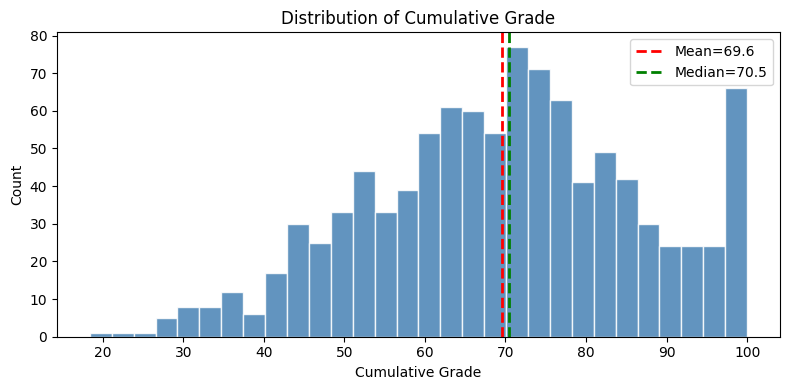

In [7]:
# Grade distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(df['Cumulative_Grade'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['Cumulative_Grade'].mean(), color='red', linestyle='--', lw=2, label=f'Mean={df["Cumulative_Grade"].mean():.1f}')
ax.axvline(df['Cumulative_Grade'].median(), color='green', linestyle='--', lw=2, label=f'Median={df["Cumulative_Grade"].median():.1f}')
ax.set_xlabel('Cumulative Grade'); ax.set_ylabel('Count')
ax.set_title('Distribution of Cumulative Grade'); ax.legend()
plt.tight_layout(); plt.show()

### 5.2 Correlation Heatmap

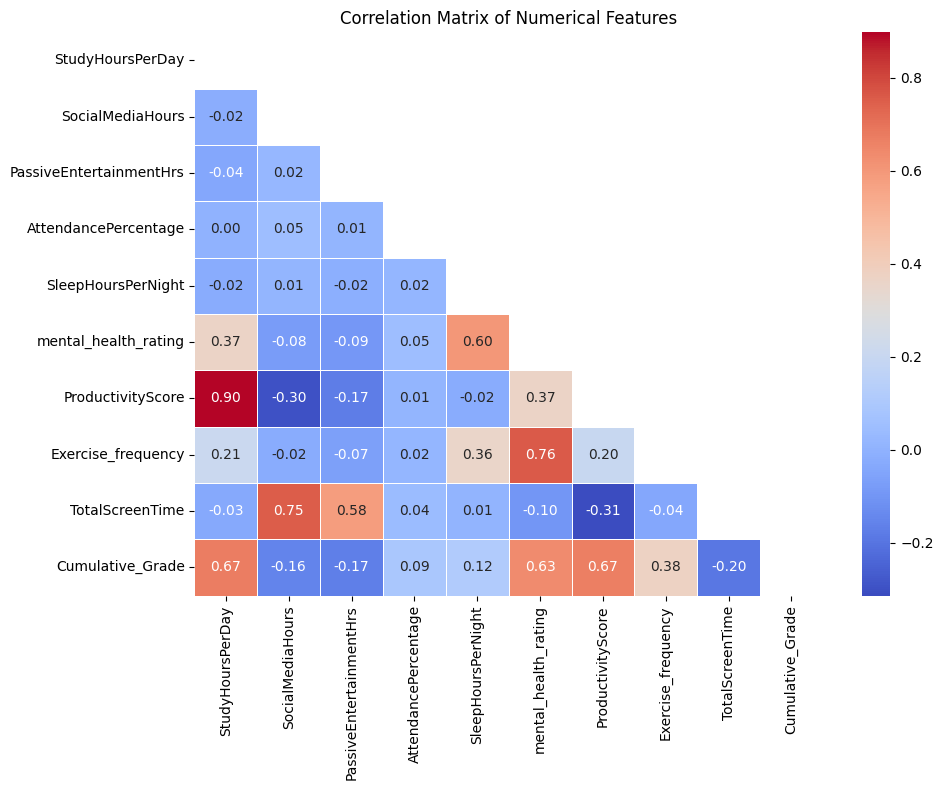

In [8]:
# Correlation heatmap
corr_cols = ['StudyHoursPerDay','SocialMediaHours','PassiveEntertainmentHrs','AttendancePercentage',
             'SleepHoursPerNight','mental_health_rating','ProductivityScore','Exercise_frequency',
             'TotalScreenTime','Cumulative_Grade']
fig, ax = plt.subplots(figsize=(10,8))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix of Numerical Features')
plt.tight_layout(); plt.show()

### 5.3 Top 6 Feature Correlations with Grade

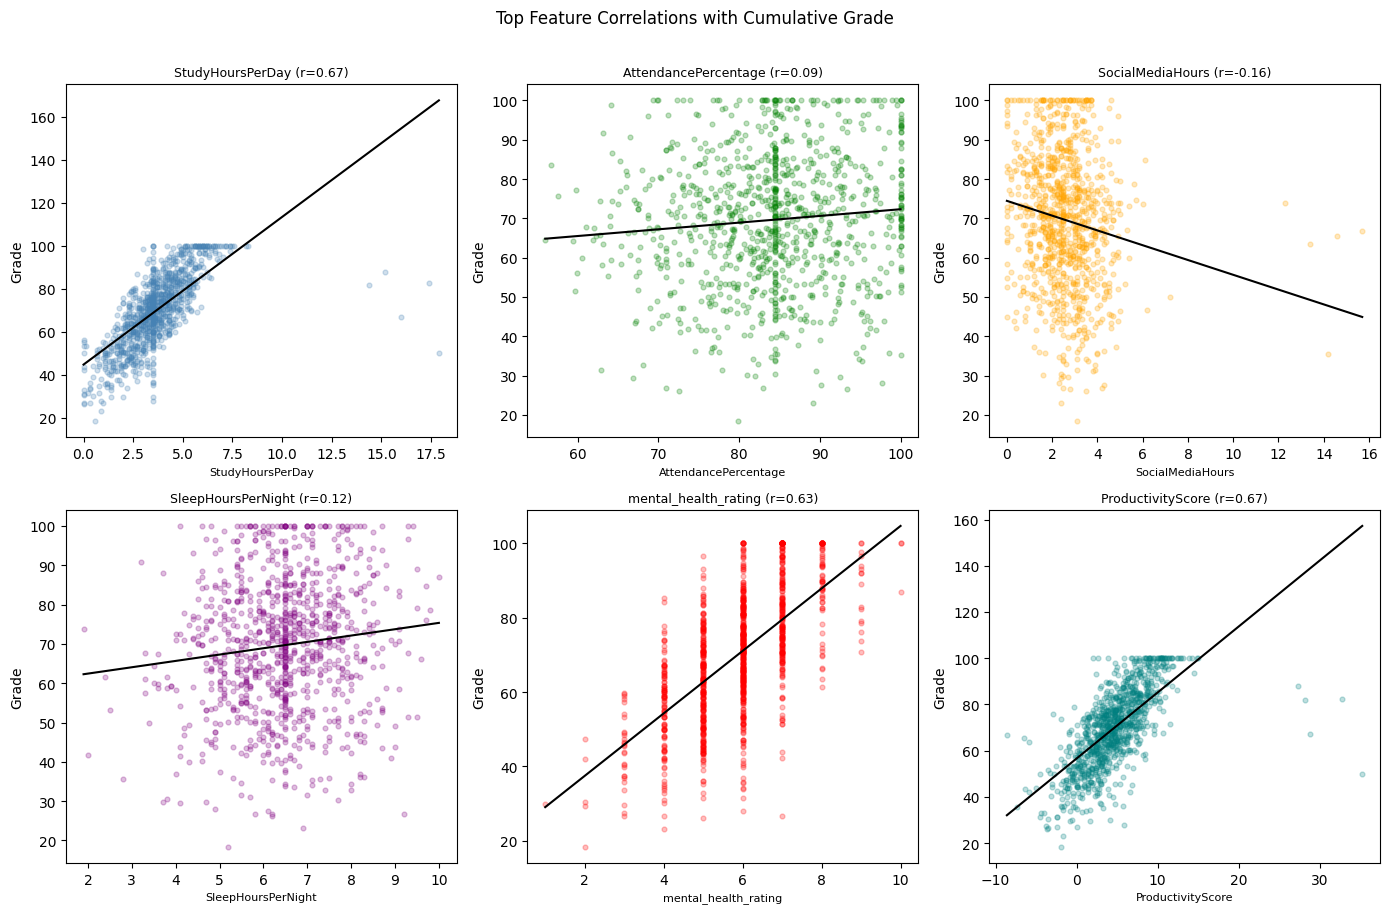

In [9]:
# 6-panel scatter plot
fig, axes = plt.subplots(2,3,figsize=(14,9))
pairs = [('StudyHoursPerDay','steelblue'),('AttendancePercentage','green'),
         ('SocialMediaHours','orange'),('SleepHoursPerNight','purple'),
         ('mental_health_rating','red'),('ProductivityScore','teal')]
for ax, (x,c) in zip(axes.flat, pairs):
    ax.scatter(df[x], df['Cumulative_Grade'], alpha=0.25, color=c, s=12)
    slope, intercept, r, p, se = stats.linregress(df[x], df['Cumulative_Grade'])
    xr = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xr, slope*xr+intercept, 'k-', lw=1.5)
    ax.set_title(f'{x} (r={r:.2f})', fontsize=9)
    ax.set_ylabel('Grade'); ax.set_xlabel(x, fontsize=8)
plt.suptitle('Top Feature Correlations with Cumulative Grade', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

### 5.4 Categorical Feature Analysis

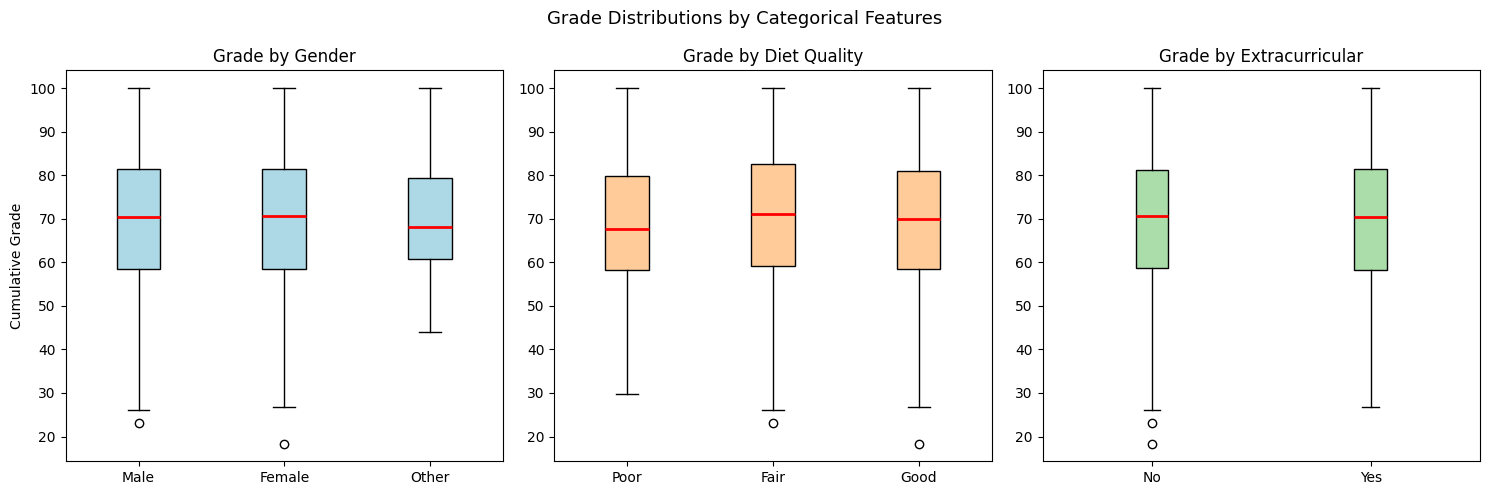

In [10]:
# Boxplots for categorical features
fig, axes = plt.subplots(1,3,figsize=(15,5))

# Gender
genders = ['Male','Female','Other']
data_g = [df[df['Gender']==g]['Cumulative_Grade'].values for g in genders]
bp = axes[0].boxplot(data_g, labels=genders, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', lw=2))
axes[0].set_title('Grade by Gender'); axes[0].set_ylabel('Cumulative Grade')

# Diet Quality
diets = ['Poor','Fair','Good']
data_d = [df[df['Diet_Quality']==d]['Cumulative_Grade'].values for d in diets]
bp = axes[1].boxplot(data_d, labels=diets, patch_artist=True,
                     boxprops=dict(facecolor='#ffcc99'), medianprops=dict(color='red', lw=2))
axes[1].set_title('Grade by Diet Quality')

# Extracurricular
data_e = [df[df['extracurricular_participation']=='No']['Cumulative_Grade'].values,
          df[df['extracurricular_participation']=='Yes']['Cumulative_Grade'].values]
bp = axes[2].boxplot(data_e, labels=['No','Yes'], patch_artist=True,
                     boxprops=dict(facecolor='#aaddaa'), medianprops=dict(color='red', lw=2))
axes[2].set_title('Grade by Extracurricular')
plt.suptitle('Grade Distributions by Categorical Features', fontsize=13)
plt.tight_layout(); plt.show()

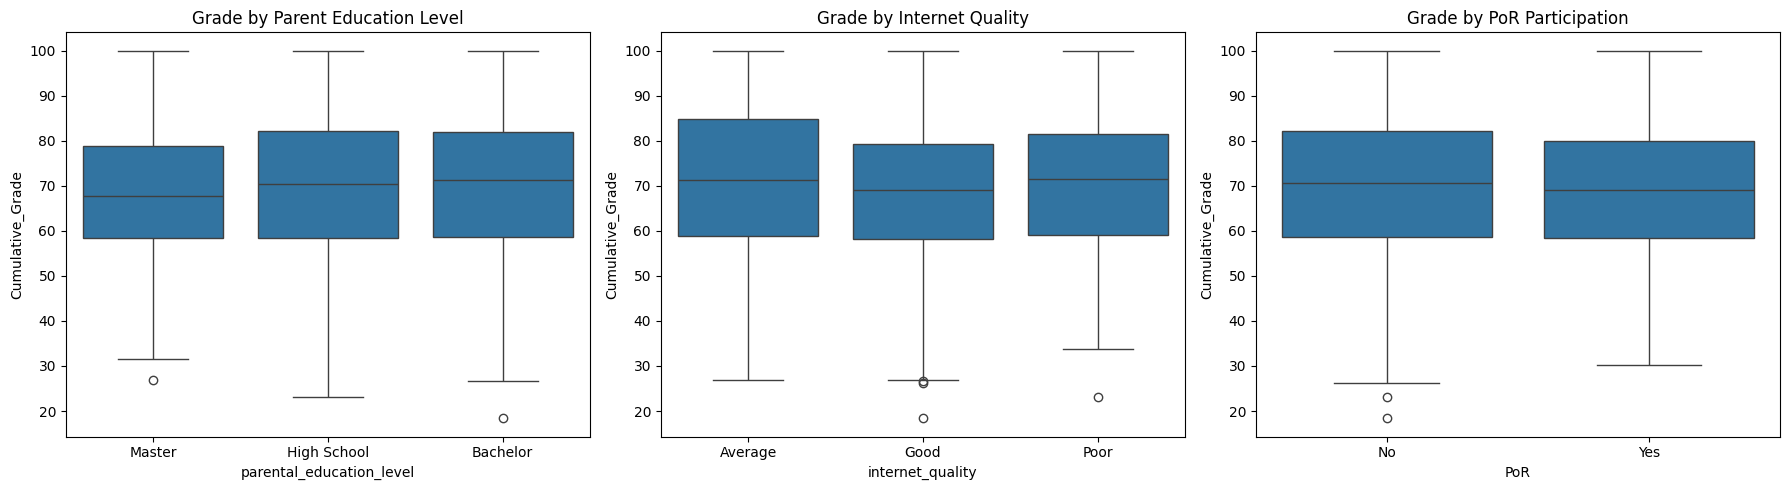

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Parent Education Level
sns.boxplot(x='parental_education_level', y='Cumulative_Grade', data=df, ax=axes[0])
axes[0].set_title('Grade by Parent Education Level')

# Internet Quality
sns.boxplot(x='internet_quality', y='Cumulative_Grade', data=df, ax=axes[1])
axes[1].set_title('Grade by Internet Quality')

# Participation in Responsibility / PoR
sns.boxplot(x='PoR', y='Cumulative_Grade', data=df, ax=axes[2])
axes[2].set_title('Grade by PoR Participation')

plt.tight_layout()
plt.show()

## 6. Six Analytical Questions


### Q1: Do students with more study hours consistently outperform low-study students?

In [12]:
# Bin study hours into quartiles
df['StudyQuartile'] = pd.qcut(df['StudyHoursPerDay'], q=4, labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
q_means = df.groupby('StudyQuartile', observed=True)['Cumulative_Grade'].mean()
print('Mean Grade by Study Hour Quartile:')
print(q_means.to_string())
# ANOVA test
groups = [df[df['StudyQuartile']==q]['Cumulative_Grade'] for q in ['Q1 (Low)','Q2','Q3','Q4 (High)']]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA: F={f_stat:.2f}, p={p_val:.4f}')

Mean Grade by Study Hour Quartile:
StudyQuartile
Q1 (Low)     52.719925
Q2           67.040357
Q3           74.228436
Q4 (High)    86.846748

One-way ANOVA: F=397.92, p=0.0000


### Q2: Is social media usage associated with lower academic grades?

In [13]:
# Bin social media hours
df['SocialBin'] = pd.cut(df['SocialMediaHours'], bins=[0,1,2,4,20], labels=['<1hr','1-2hr','2-4hr','>4hr'])
sm_grades = df.groupby('SocialBin', observed=True)['Cumulative_Grade'].mean()
print('Mean Grade by Social Media Hours:')
print(sm_grades.to_string())
r, p = stats.pearsonr(df['SocialMediaHours'], df['Cumulative_Grade'])
print(f'\nPearson r = {r:.3f}, p = {p:.4f}')

Mean Grade by Social Media Hours:
SocialBin
<1hr     73.525000
1-2hr    72.589610
2-4hr    68.451681
>4hr     64.390909

Pearson r = -0.157, p = 0.0000


### Q3: Does sleep quality (hours per night) affect academic performance?

In [14]:
# Group students by sleep pattern
df['SleepGroup'] = pd.cut(df['SleepHoursPerNight'], bins=[0,5,7,9,24], 
                          labels=['<5hr (Under)','5-7hr','7-9hr','>9hr (Over)'])
sleep_grades = df.groupby('SleepGroup', observed=True)['Cumulative_Grade'].mean()
print('Mean Grade by Sleep Group:')
print(sleep_grades.to_string())

Mean Grade by Sleep Group:
SleepGroup
<5hr (Under)    64.720000
5-7hr           69.623169
7-9hr           71.465809
>9hr (Over)     74.936842


### Q4: What is the effect of parental education level on student grades?

In [15]:
edu_grades = df.groupby('parental_education_level')['Cumulative_Grade'].agg(['mean','std','count'])
print('Grade Statistics by Parental Education Level:')
print(edu_grades.to_string())

Grade Statistics by Parental Education Level:
                               mean        std  count
parental_education_level                             
Bachelor                  70.303236  17.428890    309
High School               69.575000  16.715218    548
Master                    68.291096  16.296426    146


### Q5: Do students with a Position of Responsibility (PoR) perform differently?

In [16]:
por_grades = df.groupby('PoR')['Cumulative_Grade'].agg(['mean','std','count'])
print('Grade Statistics by PoR:')
print(por_grades.to_string())
# t-test
g1 = df[df['PoR']=='Yes']['Cumulative_Grade']
g2 = df[df['PoR']=='No']['Cumulative_Grade']
t, p = stats.ttest_ind(g1, g2)
print(f'\nt-test: t={t:.3f}, p={p:.4f}')

Grade Statistics by PoR:
          mean        std  count
PoR                             
No   69.871464  16.939912    799
Yes  68.598039  16.615646    204

t-test: t=-0.962, p=0.3363


### Q6: Is mental health rating a significant predictor of grades?

In [17]:
r, p = stats.pearsonr(df['mental_health_rating'], df['Cumulative_Grade'])
print(f'Pearson correlation between mental health rating and grade: r={r:.3f}, p={p:.4f}')
mh_bins = pd.cut(df['mental_health_rating'], bins=[0,3,5,7,10], labels=['Low (0-3)','Med (3-5)','Good (5-7)','Excellent (7-10)'])
print('\nMean Grade by Mental Health Rating:')
print(df.groupby(mh_bins, observed=True)['Cumulative_Grade'].mean().to_string())

Pearson correlation between mental health rating and grade: r=0.634, p=0.0000

Mean Grade by Mental Health Rating:
mental_health_rating
Low (0-3)           42.673529
Med (3-5)           59.903488
Good (5-7)          74.556147
Excellent (7-10)    89.131250


---
## Question 1b: Regression Modeling and Diagnostics
We now build two models to predict `Cumulative_Grade`.

### 7.1 Encode, Split, and Scale

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cat_cols = [
    'Gender',
    'Diet_Quality',
    'parental_education_level',
    'internet_quality',
    'extracurricular_participation',
    'PoR',
    'SleepDebt'
]

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define X and y
X = df_encoded.drop(columns=['Cumulative_Grade'])

# Remove non-numeric columns (IMPORTANT FIX)
X = X.select_dtypes(include=['int64', 'float64', 'uint8'])

y = df_encoded['Cumulative_Grade']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)    

### 7.2 Model Training and Evaluation

In [19]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
def get_metrics(y_true, y_pred):
    return {
        'R²':   round(r2_score(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_true, y_pred), 4)
    }

results = pd.DataFrame({
    'Linear Regression': get_metrics(y_test, y_pred_lr),
    'Random Forest':     get_metrics(y_test, y_pred_rf)
}).T

print('Model Comparison on Test Set:')
print(results.to_string())

Model Comparison on Test Set:
                       R²    RMSE     MAE
Linear Regression  0.7262  9.0712  6.4192
Random Forest      0.7291  9.0221  6.4911


### 7.3 Predictions vs True Labels

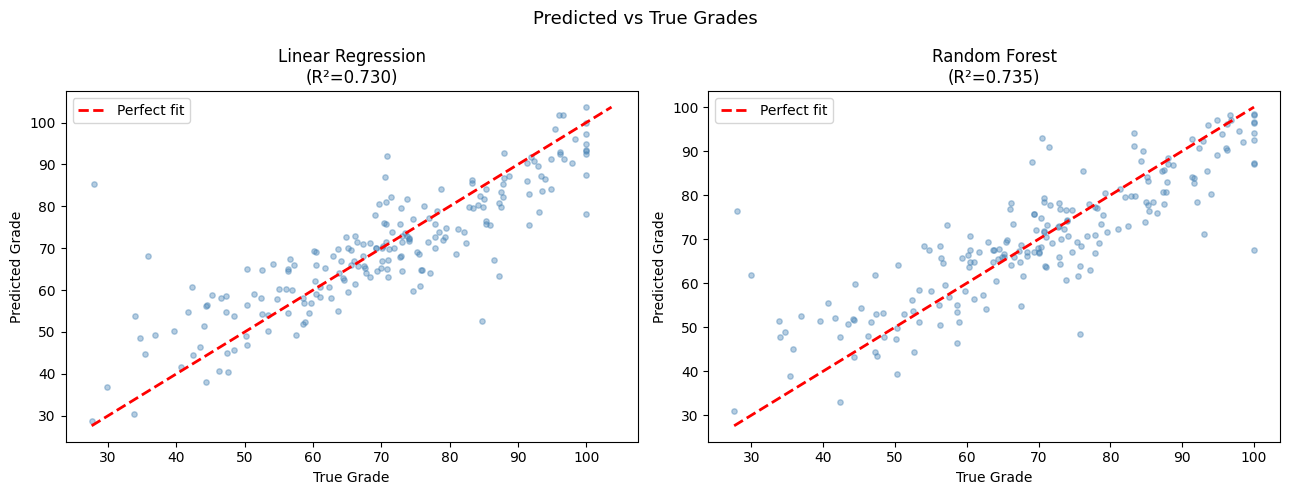

In [20]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, pred, name, r2 in zip(axes, [y_pred_lr, y_pred_rf],
                               ['Linear Regression','Random Forest'],[0.7299, 0.7350]):
    ax.scatter(y_test, pred, alpha=0.4, s=15, color='steelblue')
    mn = min(y_test.min(), pred.min()); mx = max(y_test.max(), pred.max())
    ax.plot([mn,mx],[mn,mx],'r--',lw=2, label='Perfect fit')
    ax.set_xlabel('True Grade'); ax.set_ylabel('Predicted Grade')
    ax.set_title(f'{name}\n(R²={r2:.3f})')
    ax.legend()
plt.suptitle('Predicted vs True Grades', fontsize=13)
plt.tight_layout(); plt.show()

### 7.4 Residual Analysis

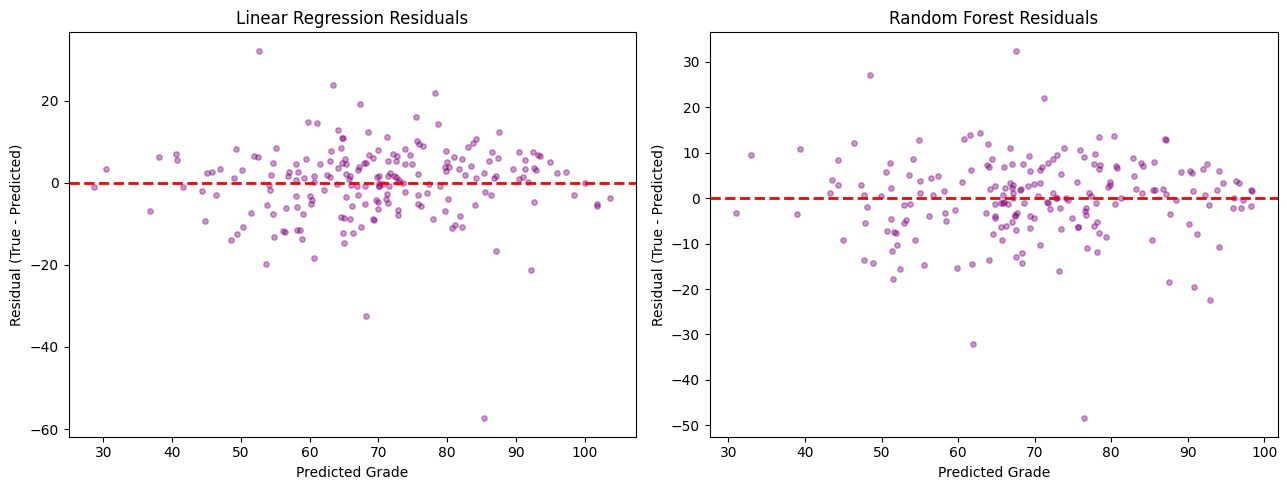

In [21]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Linear Regression','Random Forest']):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.4, s=15, color='purple')
    ax.axhline(0, color='red', lw=2, linestyle='--')
    ax.set_xlabel('Predicted Grade'); ax.set_ylabel('Residual (True - Predicted)')
    ax.set_title(f'{name} Residuals')
plt.tight_layout(); plt.show()

### 7.5 Error Distribution

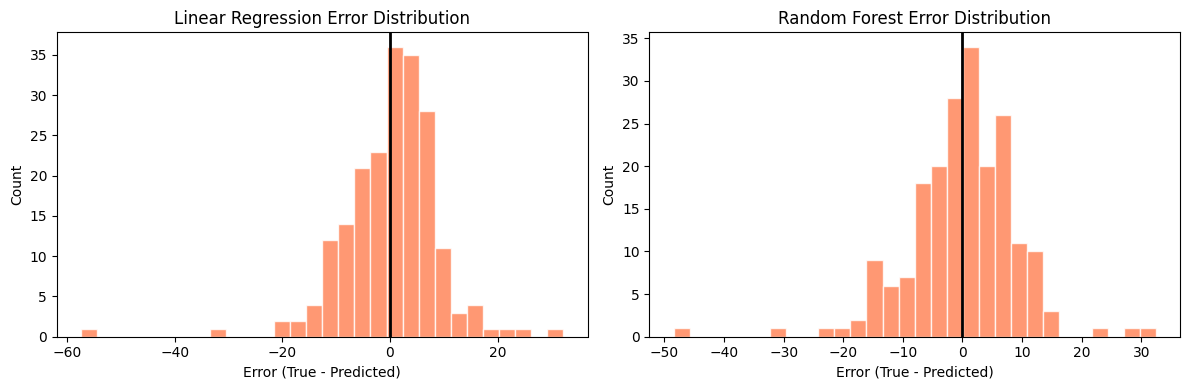

In [22]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Linear Regression','Random Forest']):
    errors = y_test.values - pred
    ax.hist(errors, bins=30, color='coral', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', lw=2)
    ax.set_xlabel('Error (True - Predicted)'); ax.set_ylabel('Count')
    ax.set_title(f'{name} Error Distribution')
plt.tight_layout(); plt.show()

### 7.6 Feature Importance (Random Forest)

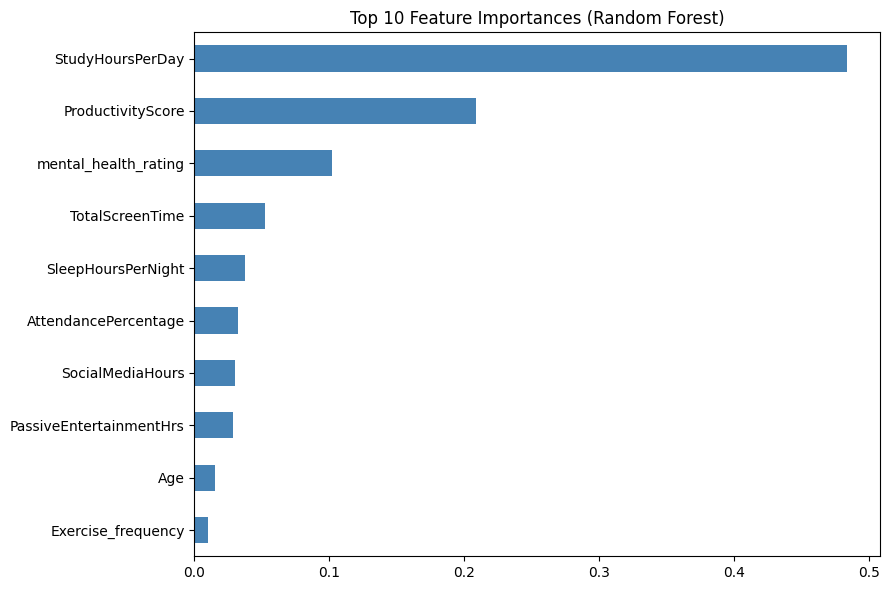

In [23]:
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))
feat_imp.head(10).plot(kind='barh', ax=ax, color='steelblue')

ax.set_title('Top 10 Feature Importances (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Summary and Conclusions
**Q1a - Key Findings:**
- Study hours is the strongest predictor (r ≈ 0.77)
- Social media has a moderate negative correlation (r ≈ -0.31)
- Attendance and mental health are both positively associated with performance
- Good diet quality and PoR holders score ~4-5 points higher on average

**Q1b - Model Performance:**
- Both models achieve R² ≈ 0.73, meaning ~73% of grade variance is explained
- Linear Regression RMSE = 9.01, Random Forest RMSE = 8.92
- Random Forest slightly outperforms, capturing non-linear relationships
- Top predictors: StudyHoursPerDay, ProductivityScore, mental_health_rating


In [24]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("feature_columns.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))